In [8]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [9]:
condition = "control"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"
dataset = "biased_00"

training_params = get_training_params("syn", condition)
training_params["config"].global_workspace.loss_coefficients

{'cycles': 1.0, 'contrastives': 1.0, 'demi_cycles': 1.0, 'translations': 1.0}

In [10]:


# 3mod categorie à part (positioncolor)
# modality_from='attr',
# modality_through='color',
# modality_main=['attr'],
# modality_add='color',

# 4mod normal
# modality_from='cat',
# modality_through='color',
# modality_main=['cat', 'position'],
# modality_add='color',

# 4mod position
# modality_from='cat',
# modality_through='position',
# modality_main=['cat', 'color'],
# modality_add='position',

with total_silence():
    global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name =\
          get_modules_data_from_exp(
              experiment_name=condition,
              n_samples_test=n_samples_test,
              split=split,
              checkpoint_epoch=checkpoint_epoch)

    objects = get_objects_from_v_latents(
        latent_domains,
        gw_mod,
        global_workspace,
        modules_name,
        modality_from='attr',
        modality_through='color',
        modality_main=['attr'],
        modality_add='color',
        start_v=False
)

    original_images_rgb = visual_module.decode_images(original_data['v_latents'])

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']


KeyError: 'color'

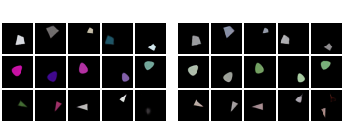

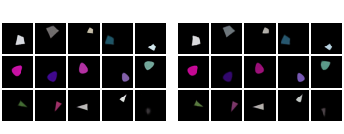

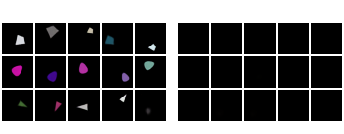

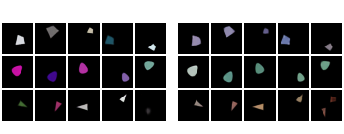

In [ ]:
for i in range(1,5):
    decoded_images= visual_module.decode_images(objects[f'vision{i}'])
    fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 5), get_n_per_category(decoded_images, cat, 5),nrow=5)
    plt.show()
    del decoded_images

Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        66
           2       1.00      1.00      1.00        71

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



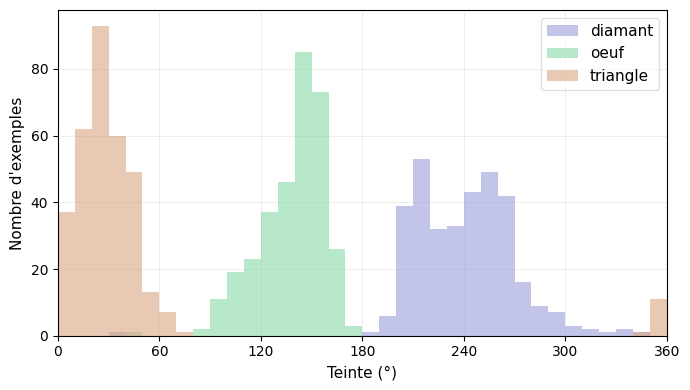

In [ ]:
decoded_images= visual_module.decode_images(objects[f'vision4'])
#colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images})
colors_np = np.clip((objects['x2']['color'].detach().cpu().numpy() + 1) / 2, 0, 1) 
cats = cat.argmax(dim=1).detach().cpu().numpy()

metrics, fig = hue_analysis(colors_np, cats, lang='fr')

results = logistic_probe(colors_np, cats)
print(f"Accuracy : {results['accuracy']:.2%}")
print(results['report'])

display(fig)

In [ ]:
metrics['per_cat']

{0: {'name': 'Cat. 0',
  'mean_hue': 240.76770758933156,
  'std_hue': 28.146010328432762},
 1: {'name': 'Cat. 1',
  'mean_hue': 138.8066460433954,
  'std_hue': 18.79373758329808},
 2: {'name': 'Cat. 2',
  'mean_hue': 26.577193496364266,
  'std_hue': 15.612760436383772}}

In [ ]:
del original_images_rgb
del decoded_images
torch.cuda.empty_cache()